# z50-ratio vr-scaling A-sweep: z=0 comparison

Processes the combined abundance-matching HDF5 that `src/environment_test/run_abundance.py`
writes for the full-sample z50-ratio vr-scaling test (`vr' = [1 + A(rat-1)] vr`,
`rat = (1+z50)/(1+\langle z50\rangle)`, `\langle z50\rangle = 0.9304333832432538` -- see
`z50_vr_scale_test` project notes) into a combined z0 summary CSV via
`jsm_processh5.ProcessH5`, then makes the standard corner plot (1D/2D KDE
marginals + Spearman rank-order correlations per model) this project already
uses for every other model-comparison notebook (`epsilon_vs_fiducial.ipynb`,
`bolshoi_rep.ipynb`).

The A-model set (`A0.20`/`A0.40`/`A0.60`/`A0.80` by default) is **discovered
directly from the h5's own top-level groups**, not hardcoded -- this notebook
runs correctly even if only some A's have finished integrating/measuring on
the server so far. There is no A=0/unscaled baseline in this sweep (see
project notes, Part 5) -- this compares the A-scaled models against each
other, not against an unscaled case.

`logc` uses `ProcessH5(..., conctype=None)` -- the *analytic* Zhao et al.
(2009) host concentration, matching every other paper-3 comparison notebook's
convention.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import itertools

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../../../SatGen/mcmc/src/')
sys.path.insert(0, '../../../SatGen/src/')
import jsm_processh5
import jsm_stats

import warnings; warnings.simplefilter('ignore')

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0  # inches
single_textwidth = 3.5  # inches

LEVELZ = [1 - 0.99, 1 - 0.95, 1 - 0.68]  # 99/95/68% 2D KDE contour levels

## Load the combined h5 and build the z0 CSV

Reads whatever `A{A:.2f}` groups currently exist in the combined h5, builds
the z0 summary table across all of them with `jsm_processh5.ProcessH5`, and
saves it as one combined long-format CSV (`source_file` column tags each
row's model, e.g. `"...z50_ratio_A_sweep.h5/A0.20"`).

In [4]:
H5_PATH = "../../data/environment_test/z50_ratio_A_sweep.h5"
DATA_DIR = "../../data/environment_test"
CSV_LABEL = "z50_ratio_A_sweep"
CONCTYPE = None  # analytic Zhao et al. 2009 host_c -- matches every other paper-3 comparison notebook

with h5py.File(H5_PATH, "r") as f:
    A_labels = sorted(f.keys())
print(f"found {len(A_labels)} model group(s) in {H5_PATH}: {A_labels}")

files = [(H5_PATH, group) for group in A_labels]
proc = jsm_processh5.ProcessH5(datadir=DATA_DIR, files=files, conctype=CONCTYPE, label=CSV_LABEL)
proc.build_z0_table()
csv_path = proc.save_z0_csv()
print(f"saved {len(proc.z0_table)}-row z0 table -> {csv_path}")
proc.z0_table.head()

found 4 model group(s) in ../../data/environment_test/z50_ratio_A_sweep.h5: ['A0.20', 'A0.40', 'A0.60', 'A0.80']
ProcessH5: found 4 h5 file(s) in ../../data/environment_test
  z0: z50_ratio_A_sweep.h5/A0.20 -> 1000 trees (6.6s)
  z0: z50_ratio_A_sweep.h5/A0.40 -> 1000 trees (6.7s)
  z0: z50_ratio_A_sweep.h5/A0.60 -> 1000 trees (6.3s)
  z0: z50_ratio_A_sweep.h5/A0.80 -> 1000 trees (6.4s)
saved 4000 rows -> ../../data/environment_test/z50_ratio_A_sweep_z0.csv
saved 4000-row z0 table -> ../../data/environment_test/z50_ratio_A_sweep_z0.csv


,tree_index,source_file,logMvir,log1pz50,logc,Nsub,logNsub,fsub,logfsub,MMs,logMMs
0,10000,z50_ratio_A_sweep.h5/A0.20,13.0,0.299100,1.013444,1.0,0.000000,0.007846,-2.105379,0.007846,-2.105379
1,10658,z50_ratio_A_sweep.h5/A0.60,13.0,0.159264,1.063715,6.0,0.778151,0.189357,-0.722718,0.072722,-1.138336
2,10659,z50_ratio_A_sweep.h5/A0.60,13.0,0.312405,1.169962,1.0,0.000000,0.015928,-1.797837,0.015928,-1.797837
3,10660,z50_ratio_A_sweep.h5/A0.60,13.0,0.230368,0.916473,1.0,0.000000,0.133171,-0.875590,0.133171,-0.875590
4,10661,z50_ratio_A_sweep.h5/A0.60,13.0,0.276889,0.938653,3.0,0.477121,0.028968,-1.538078,0.010442,-1.981235


## Match models by tree_index

Splits the long-format z0 table back out by A-label, suffixes each model's
columns (`add_suffix`), and chain-merges them on `tree_index` (inner join --
only trees successfully measured in *every* shown A survive into `matched`).
Same pattern as `bolshoi_rep.ipynb`.

In [5]:
def add_suffix(df, suf):
    return df.rename(columns={c: f"{c}_{suf}" for c in df.columns if c != "tree_index"})


model_dfs = {}
for label in A_labels:
    sub = proc.z0_table[proc.z0_table["source_file"].str.endswith(f"/{label}")].drop(columns=["source_file"])
    if sub.empty:
        print(f"  (skipping {label}: no rows in the z0 table for it)")
        continue
    model_dfs[label] = sub

models = [(label, label) for label in model_dfs]
frames = [add_suffix(df, suf) for suf, df in model_dfs.items()]
matched = frames[0]
for frame in frames[1:]:
    matched = matched.merge(frame, on="tree_index", how="inner")

print(f"{len(matched)} trees matched by tree_index across {len(models)} models "
      "(of " + ", ".join(f"{len(model_dfs[suf])} {suf}" for suf, _ in models) + ")")

1000 trees matched by tree_index across 4 models (of 1000 A0.20, 1000 A0.40, 1000 A0.60, 1000 A0.80)


## Standard corner plot (with rank-order correlations)

Diagonal = 1D KDE marginal per model; lower triangle = 2D KDE contours at the
68/95/99% levels; each off-diagonal panel is annotated with the Spearman
rank-order correlation (`jsm_stats.correlation`) per model, color-coded.
Generalized N-model version of `plot_corner_with_corr`, copied from
`bolshoi_rep.ipynb`. `logMvir` is excluded from the keys below (single 13.0
mass-bin sample, no mass spread to show -- same reasoning as
`epsilon_vs_fiducial.ipynb`, not `bolshoi_rep.ipynb`'s multi-mass-bin
version).

In [6]:
def plot_corner_with_corr(matched, models, keys, paramNames, colors, paramRanges=None, figsize=9.0):
    model_colors = dict(zip([m for _, m in models], colors))
    model_chains = {}
    model_rho = {}
    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys
        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)
        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1].values, chain[k2].values)
        model_chains[model] = chain
        model_rho[model] = pair_rho

    if paramRanges is None:
        paramRanges = []
        for k in keys:
            allvals = np.concatenate([model_chains[m][k].values for _, m in models])
            allvals = allvals[np.isfinite(allvals)]
            lo, hi = np.nanpercentile(allvals, [1, 99])
            pad = 0.5 * (hi - lo if hi > lo else 1.0)
            paramRanges.append([lo - pad, hi + pad])

    nDim = len(keys)
    fig, axes = plt.subplots(nDim, nDim, figsize=(figsize, figsize))
    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue
            if i == j:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(chain[keys[i]], ax=ax, color=model_colors[model], fill=False, lw=1.8)
                ax.set_xlim(paramRanges[i]); ax.set_yticks([])
            else:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(x=chain[keys[j]], y=chain[keys[i]], ax=ax, color=model_colors[model],
                                levels=LEVELZ, fill=False, linewidths=1.3)
                ax.set_xlim(paramRanges[j]); ax.set_ylim(paramRanges[i])
                pair = (keys[j], keys[i])
                first_model = models[0][1]
                if pair not in model_rho[first_model]:
                    pair = (keys[i], keys[j])
                y0 = 0.92
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(0.55, y0, "$\\rho$=" + f"{rho:.2f}", transform=ax.transAxes, fontsize=8,
                            color=model_colors[model],
                            bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k", pad=0.15))
                    y0 -= 0.13
            if i == nDim - 1:
                ax.set_xlabel(paramNames[j])
            else:
                ax.set_xticklabels([])
            if j == 0 and i != 0:
                ax.set_ylabel(paramNames[i])
            elif j == 0 and i == 0:
                pass
            else:
                ax.set_yticklabels([])

    handles = [plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model) for _, model in models]
    fig.legend(handles=handles, loc="upper right", fontsize=11, frameon=False)
    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig

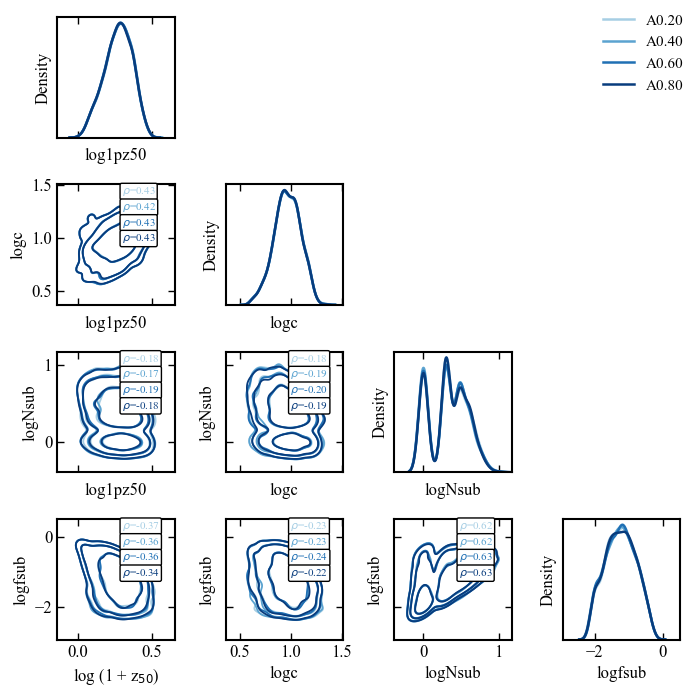

In [7]:
keys = ["log1pz50", "logc", "logNsub", "logfsub"]
paramNames = ["log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"]

# Blues ramp across the A-labels present -- same A-value color convention
# environment_test.ipynb already established for this test (darker = stronger scaling)
colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(models))) if len(models) > 1 else ["steelblue"]

fig = plot_corner_with_corr(matched, models=models, keys=keys, paramNames=paramNames,
                             colors=colors, figsize=double_textwidth)
# fig.savefig("../../figures/z50_ratio_A_sweep_corner.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only

## Rank-order correlation vs A

Spearman rank correlation (with jackknife error bars, `jsm_stats.jackknife_correlation`)
between four (subhalo abundance) x (formation/concentration) pairs, plotted as a
function of the scaling strength A. Same diagnostic as `epsilon_vs_fiducial.ipynb`'s
`rank_corr_vs_A`.

**The A=0 point reuses `data/epsilon/fiducial.h5`** -- the epsilon test's own
no-perturbation baseline, i.e. genuinely the same "no scaling applied" case this
sweep's own A=0 would be. **Important: its `tree_index` values (10000-10999) do
NOT correspond to this sweep's local tree indices ("30"/"31"/... etc, matching
`tree_13.0_*.npz`)** -- checked directly (2026-09-04): `fiducial.h5`'s tree
"10030"'s `host_z50` does not match local tree "30"'s known z50, so these are
different tree_index numbering schemes, not a simple offset, and there's no
known per-tree correspondence between the two files. So the A=0 point below is
computed as an **independent** correlation over `fiducial.h5`'s own ~1000 trees
(its own jackknife error bars, from its own full sample size) -- NOT matched by
tree_index to the A>0 sweep points, which stay matched among themselves via the
`matched` table built above. This also sidesteps needing an `A0.00` group in the
sweep's own combined h5 at all.

In [8]:
FIDUCIAL_H5_PATH = "../../data/epsilon/fiducial.h5"  # epsilon test's own no-perturbation
                                                        # baseline, reused here as this
                                                        # sweep's A=0 point (see project notes, Part 7)

fid_proc = jsm_processh5.ProcessH5(datadir=DATA_DIR, files=[FIDUCIAL_H5_PATH],
                                    conctype=CONCTYPE, label="fiducial")
fid_proc.build_z0_table()
fid_df = fid_proc.z0_table
print(f"fiducial baseline: {len(fid_df)} trees from {FIDUCIAL_H5_PATH}")

ProcessH5: found 1 h5 file(s) in ../../data/environment_test
  z0: fiducial.h5 -> 1000 trees (7.1s)
fiducial baseline: 1000 trees from ../../data/epsilon/fiducial.h5


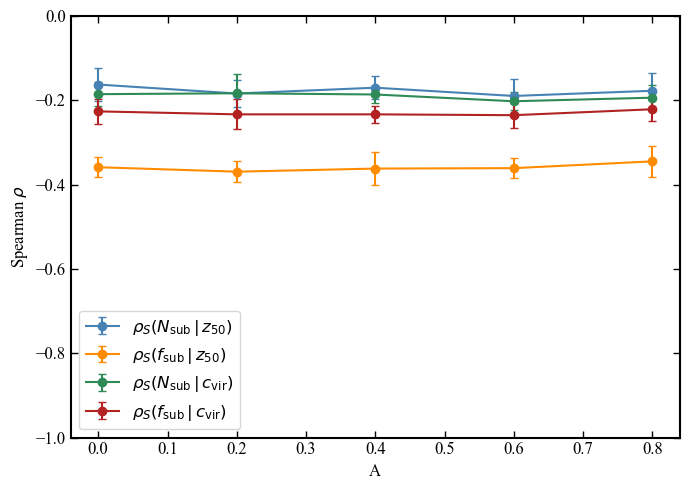

In [10]:
def rank_corr_vs_A(matched, sweep_points, fid_df, pairs, n_jack=10, figsize=(7, 5)):
    """
    Spearman rank correlation (with jackknife error bars) as a function of
    A, for each (xcol, ycol, label, color) in `pairs`. Adapted from
    epsilon_vs_fiducial.ipynb's rank_corr_vs_A: the A=0 point is computed
    independently from `fid_df` (its own full sample, own jackknife error
    bars -- NOT matched by tree_index to the sweep, see the markdown note
    above), while the A>0 points come from `matched` (this notebook's own
    tree_index-matched A-sweep table).

    sweep_points : list of (suffix, A_value) tuples for A>0, e.g.
                   [("A0.20", 0.2), ("A0.40", 0.4), ...] -- `matched` must
                   have columns f"{xcol}_{suffix}" / f"{ycol}_{suffix}"
                   for every suffix in `sweep_points`.
    """
    fig, ax = plt.subplots(figsize=figsize)
    for xcol, ycol, label, color in pairs:
        A_vals, rhos, errs = [0.0], [], []

        x0 = fid_df[xcol].values
        y0 = fid_df[ycol].values
        mask0 = np.isfinite(x0) & np.isfinite(y0)
        rho0, err0, _ = jsm_stats.jackknife_correlation(x0[mask0], y0[mask0], n_jack=n_jack)
        rhos.append(rho0)
        errs.append(err0)

        for suf, A in sweep_points:
            A_vals.append(A)
            x = matched[f"{xcol}_{suf}"].values
            y = matched[f"{ycol}_{suf}"].values
            mask = np.isfinite(x) & np.isfinite(y)
            rho, rho_err, _ = jsm_stats.jackknife_correlation(x[mask], y[mask], n_jack=n_jack)
            rhos.append(rho)
            errs.append(rho_err)

        ax.errorbar(A_vals, rhos, yerr=errs, marker="o", capsize=3, label=label, color=color)

    ax.set_xlabel("A")
    ax.set_ylabel(r"Spearman $\rho$")
    ax.set_ylim(-1, 0)
    ax.legend()
    plt.tight_layout()
    return fig


rank_corr_pairs = [
    ("logNsub", "log1pz50", r"$\rho_S(N_{\rm sub}\,|\,z_{50})$", "steelblue"),
    ("logfsub", "log1pz50", r"$\rho_S(f_{\rm sub}\,|\,z_{50})$", "darkorange"),
    ("logNsub", "logc",     r"$\rho_S(N_{\rm sub}\,|\,c_{\rm vir})$", "seagreen"),
    ("logfsub", "logc",     r"$\rho_S(f_{\rm sub}\,|\,c_{\rm vir})$", "firebrick"),
]

rank_corr_sweep_points = sorted(
    ((label, float(label[1:])) for label in A_labels),
    key=lambda p: p[1],
)
fig_rank_corr = rank_corr_vs_A(matched, rank_corr_sweep_points, fid_df, rank_corr_pairs)
# fig_rank_corr.savefig("../../figures/z50_ratio_A_sweep_rank_corr_vs_A.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only